In [2]:
import pandas as pd

df = pd.read_csv("D:/DS_App User Behavior Segmentation/Data/user_behavior_dataset.csv")

df.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB


In [4]:
df.describe()

,User ID,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class
count,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,350.50000,271.128571,5.272714,1525.158571,50.681429,929.742857,38.482857,2.990000
std,202.21688,177.199484,3.068584,819.136414,26.943324,640.451729,12.012916,1.401476
min,1.00000,30.000000,1.000000,302.000000,10.000000,102.000000,18.000000,1.000000
25%,175.75000,113.250000,2.500000,722.250000,26.000000,373.000000,28.000000,2.000000
50%,350.50000,227.500000,4.900000,1502.500000,49.000000,823.500000,38.000000,3.000000
75%,525.25000,434.250000,7.400000,2229.500000,74.000000,1341.000000,49.000000,4.000000
max,700.00000,598.000000,12.000000,2993.000000,99.000000,2497.000000,59.000000,5.000000


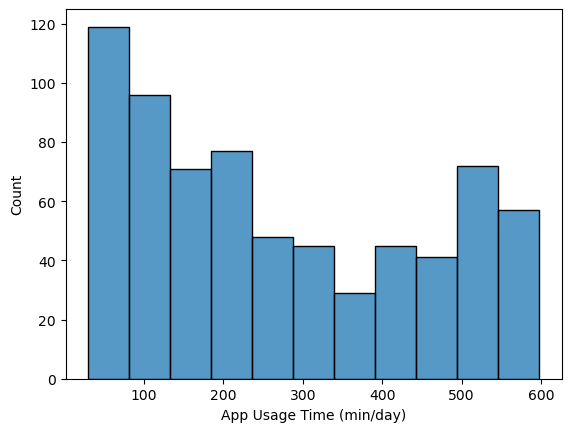

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['App Usage Time (min/day)'])
plt.show()

In [6]:
df['engagement_score'] = (
    df['App Usage Time (min/day)'] * 
    df['Number of Apps Installed']
)

In [7]:
df['battery_per_min'] = (
    df['Battery Drain (mAh/day)'] / 
    df['App Usage Time (min/day)']
)

In [8]:
df['data_per_app'] = (
    df['Data Usage (MB/day)'] / 
    df['Number of Apps Installed']
)

In [9]:
df['screen_usage_ratio'] = (
    df['Screen On Time (hours/day)'] * 60 / 
    df['App Usage Time (min/day)']
)

In [10]:
df = pd.get_dummies(df, columns=['Gender', 'Operating System'], drop_first=True)

In [11]:
df.head()

,User ID,Device Model,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class,engagement_score,battery_per_min,data_per_app,screen_usage_ratio,Gender_Male,Operating System_iOS
0,1,Google Pixel 5,393,6.4,1872,67,1122,40,4,26331,4.763359,16.746269,0.977099,True,False
1,2,OnePlus 9,268,4.7,1331,42,944,47,3,11256,4.966418,22.476190,1.052239,False,False
2,3,Xiaomi Mi 11,154,4.0,761,32,322,42,2,4928,4.941558,10.062500,1.558442,True,False
3,4,Google Pixel 5,239,4.8,1676,56,871,20,3,13384,7.012552,15.553571,1.205021,True,False
4,5,iPhone 12,187,4.3,1367,58,988,31,3,10846,7.310160,17.034483,1.379679,False,True


In [12]:
from sklearn.preprocessing import StandardScaler

features = df.drop(['User ID', 'Device Model'], axis=1)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

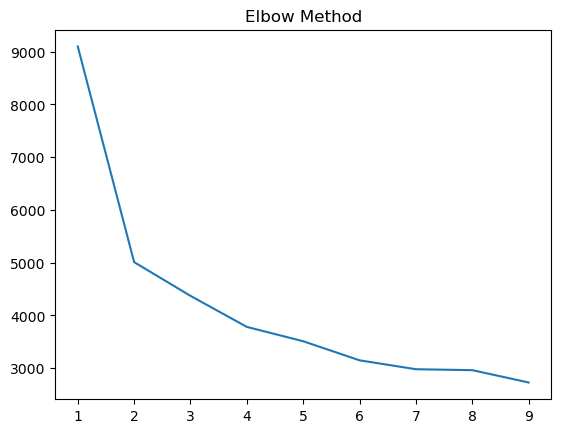

In [36]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.title("Elbow Method")
plt.show()

In [16]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_data)

In [18]:
df.groupby('cluster').mean(numeric_only=True)

,User ID,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class,engagement_score,battery_per_min,data_per_app,screen_usage_ratio,Gender_Male,Operating System_iOS
cluster,,,,,,,,,,,,,,
0,341.226277,540.919708,10.098540,2698.029197,89.051095,1971.102190,38.218978,4.992701,48171.649635,5.002499,22.226557,1.124284,0.562044,0.226277
1,352.407240,109.588235,2.359276,700.497738,24.085973,351.203620,38.167421,1.592760,2912.199095,6.564718,14.965770,1.310777,0.542986,0.208145
2,348.539683,57.904762,2.112698,614.365079,19.603175,272.777778,38.888889,1.301587,1331.666667,11.139126,14.336760,2.288471,0.587302,0.126984
3,353.985663,314.756272,5.924373,1808.121864,59.924731,1025.010753,38.770609,3.494624,19640.695341,6.007007,17.152937,1.179806,0.465950,0.218638


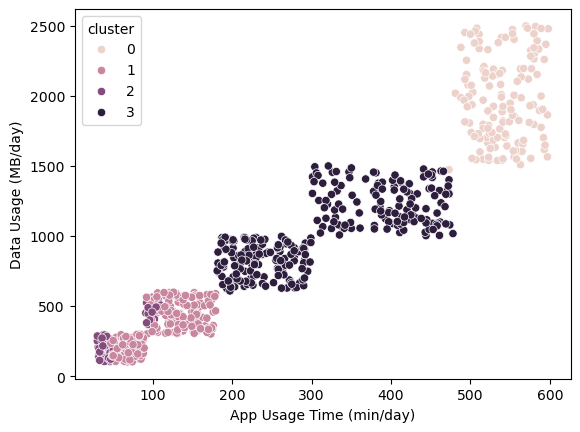

In [19]:
sns.scatterplot(
    x='App Usage Time (min/day)', 
    y='Data Usage (MB/day)', 
    hue='cluster', 
    data=df
)
plt.show()

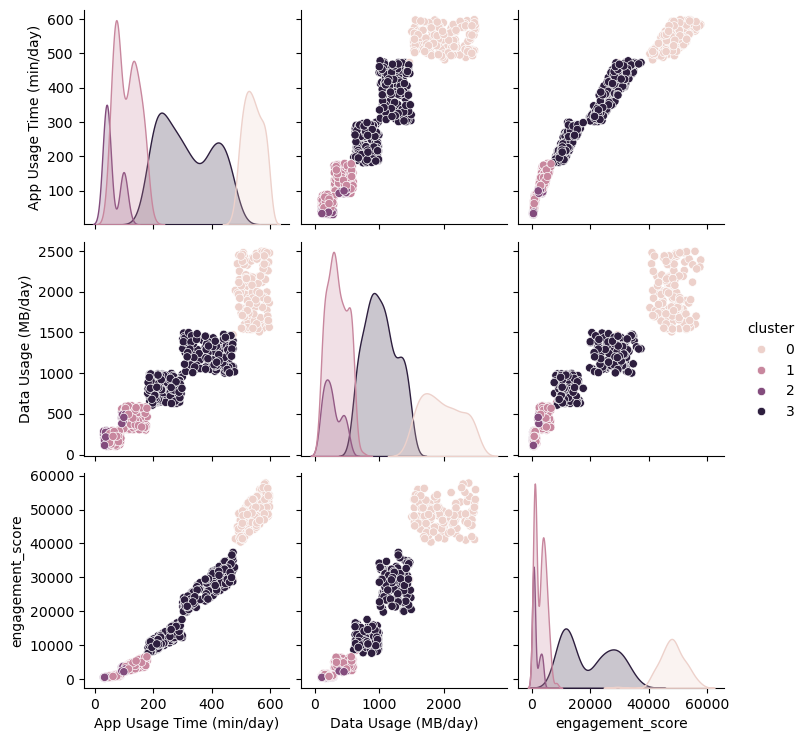

In [46]:
import seaborn as sns

sns.pairplot(df, hue='cluster', vars=[
    'App Usage Time (min/day)',
    'Data Usage (MB/day)',
    'engagement_score'
])

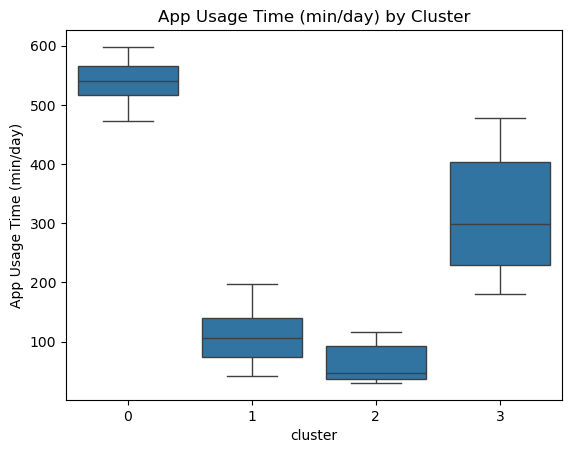

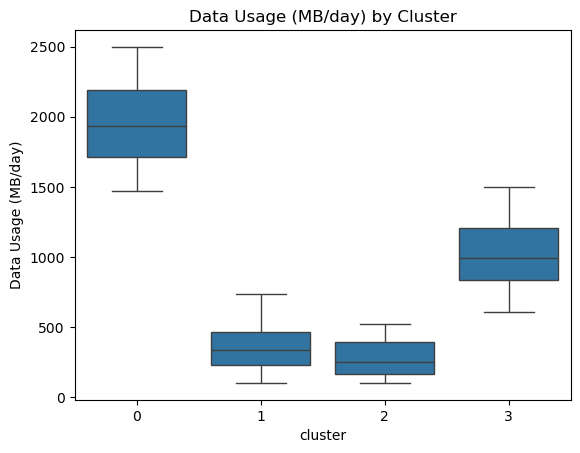

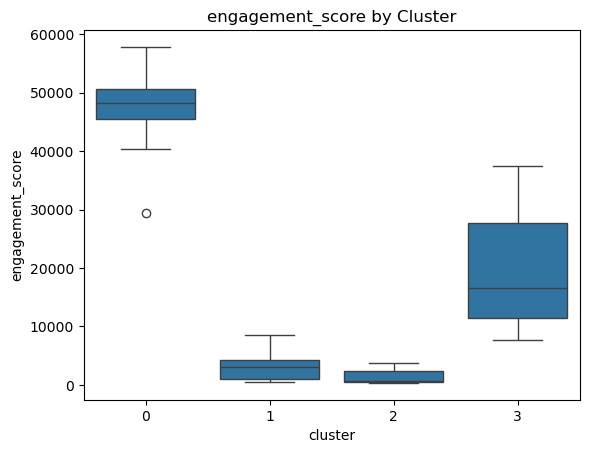

In [44]:
import matplotlib.pyplot as plt

features = [
    'App Usage Time (min/day)',
    'Data Usage (MB/day)',
    'engagement_score'
]

for feature in features:
    sns.boxplot(x='cluster', y=feature, data=df)
    plt.title(f"{feature} by Cluster")
    plt.show()
    

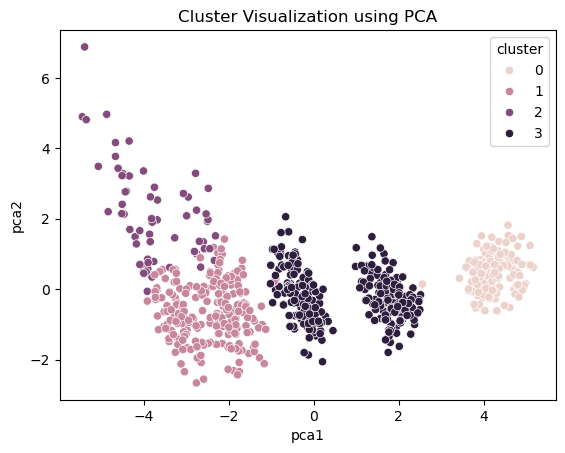

In [34]:
sns.scatterplot(x='pca1', y='pca2', hue='cluster', data=df)
plt.title("Cluster Visualization using PCA")
plt.show()

In [21]:
df['power_user_score'] = (
    df['App Usage Time (min/day)'] * 0.4 +
    df['Data Usage (MB/day)'] * 0.3 +
    df['Number of Apps Installed'] * 0.3
)

In [22]:
df['efficiency_score'] = (
    df['App Usage Time (min/day)'] / 
    df['Battery Drain (mAh/day)']
)

In [23]:
df['age_group'] = pd.cut(
    df['Age'],
    bins=[0,25,40,60],
    labels=['Young','Adult','Senior']
)

In [24]:
df = pd.get_dummies(df, columns=['age_group'], drop_first=True)

In [25]:
premium_devices = ['iPhone 12', 'Samsung Galaxy S21']

df['is_premium_device'] = df['Device Model'].apply(
    lambda x: 1 if x in premium_devices else 0
)

In [26]:
df['high_engagement'] = df['engagement_score'].apply(
    lambda x: 1 if x > df['engagement_score'].mean() else 0
)

In [27]:
from sklearn.model_selection import train_test_split

X = df.drop(['high_engagement', 'User ID', 'Device Model'], axis=1)
y = df['high_engagement']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic:", accuracy_score(y_test, y_pred))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Logistic: 1.0
Random Forest: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        90
           1       1.00      1.00      1.00        50

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



In [31]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_, 
    index=X.columns
).sort_values(ascending=False)

print(importance)

Data Usage (MB/day)           0.184624
Battery Drain (mAh/day)       0.137096
App Usage Time (min/day)      0.131528
User Behavior Class           0.126098
power_user_score              0.120286
Number of Apps Installed      0.113302
engagement_score              0.090034
Screen On Time (hours/day)    0.070435
battery_per_min               0.010604
efficiency_score              0.006748
cluster                       0.003975
data_per_app                  0.002774
screen_usage_ratio            0.002496
Age                           0.000000
Operating System_iOS          0.000000
Gender_Male                   0.000000
age_group_Adult               0.000000
age_group_Senior              0.000000
is_premium_device             0.000000
dtype: float64


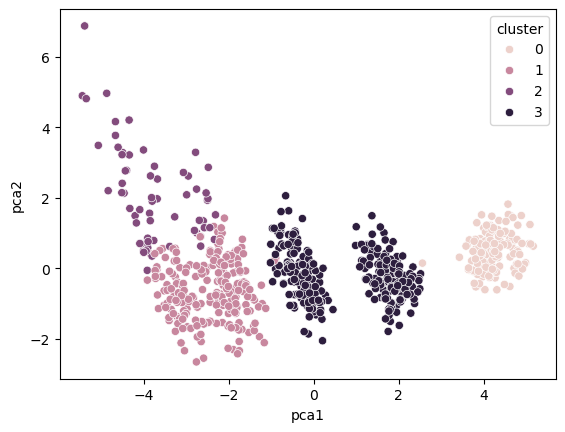

In [40]:
sns.scatterplot(x='pca1', y='pca2', hue='cluster', data=df)

plt.savefig("D:/DS_App User Behavior Segmentation/Images/pca_plot.png")
plt.show()